In [34]:
import os
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

from collections import Counter

import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import (
    preprocess_input
)

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

from tensorflow.keras.utils import Sequence

In [4]:
IMAGE_DIR = "../datasets/sampled_sneakers_1024x1024"

CSV_PATH = "../datasets/triplet_dataset_hard.csv"

IMAGE_SIZE = (224,224)

BATCH_SIZE = 16

MARGIN = 0.3

EMBEDDING_DIM = 128

In [5]:
triplets_df = pd.read_csv(
    CSV_PATH
)

print(
    len(triplets_df)
)

triplets_df.head()

22580


,anchor_image,positive_image,negative_image,anchor_brand,negative_brand
0,resized_padded_underarmour_102.jpg,resized_padded_underarmour_91.jpg,resized_padded_new_newbalance_154.jpg,underarmour,newbalance
1,resized_padded_new_newbalance_170.jpg,resized_padded_new_newbalance_150.jpg,resized_padded_vans_370.jpg,newbalance,vans
2,resized_padded_puma_119.jpg,resized_padded_puma_349.jpg,resized_padded_underarmour_78.jpg,puma,underarmour
3,resized_padded_underarmour_69.jpg,resized_padded_underarmour_262.jpg,normalized_nike_118.jpg,underarmour,nike
4,resized_all_vans_216.jpg,resized_padded_vans_503.jpg,resized_padded_reebok_362.jpg,vans,reebok


In [6]:
def load_and_preprocess_image(
    image_path
):

    image = load_img(
        image_path,
        target_size=IMAGE_SIZE
    )

    image = img_to_array(
        image
    )

    image = preprocess_input(
        image
    )

    return image

In [7]:
class TripletGenerator(
    Sequence
):

    def __init__(
        self,
        dataframe,
        image_dir,
        batch_size=16
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.image_dir = image_dir

        self.batch_size = batch_size

    def __len__(self):

        return int(
            np.ceil(
                len(self.df)
                /
                self.batch_size
            )
        )

    def __getitem__(
        self,
        index
    ):

        batch = self.df.iloc[
            index*self.batch_size:
            (index+1)*self.batch_size
        ]

        anchors = []
        positives = []
        negatives = []

        for _, row in batch.iterrows():

            anchor_path = os.path.join(
                self.image_dir,
                row["anchor_image"]
            )

            positive_path = os.path.join(
                self.image_dir,
                row["positive_image"]
            )

            negative_path = os.path.join(
                self.image_dir,
                row["negative_image"]
            )

            anchors.append(
                load_and_preprocess_image(
                    anchor_path
                )
            )

            positives.append(
                load_and_preprocess_image(
                    positive_path
                )
            )

            negatives.append(
                load_and_preprocess_image(
                    negative_path
                )
            )

        return (
            (
                np.array(anchors),
                np.array(positives),
                np.array(negatives)
            ),
            np.zeros(
                len(batch)
            )
        )

In [8]:
train_generator = TripletGenerator(
    triplets_df,
    IMAGE_DIR,
    BATCH_SIZE
)

print(
    len(train_generator)
)

1412


In [25]:
(
    anchor_batch,
    positive_batch,
    negative_batch
), _ = train_generator[0]

print(anchor_batch.shape)

print(positive_batch.shape)

print(negative_batch.shape)

(16, 224, 224, 3)
(16, 224, 224, 3)
(16, 224, 224, 3)


In [9]:
class L2Normalize(
    tf.keras.layers.Layer
):

    def call(
        self,
        inputs
    ):

        return tf.math.l2_normalize(
            inputs,
            axis=1
        )

In [10]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

In [12]:
inputs = Input(
    shape=(224,224,3)
)

x = base_model(inputs)

x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation="relu"
)(x)

x = Dropout(
    0.4
)(x)

x = Dense(
    EMBEDDING_DIM
)(x)

outputs = L2Normalize()(x)

In [13]:
embedding_model = Model(
    inputs,
    outputs,
    name="embedding_model"
)

In [14]:
embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ l2_normalize_1 (L2Normalize)         │ (None, 128)                 │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,702,464 (94.23 MB)

 Trainable params: 10,046,080 (38.32 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

In [15]:
anchor_input = Input(
    shape=(224,224,3)
)

positive_input = Input(
    shape=(224,224,3)
)

negative_input = Input(
    shape=(224,224,3)
)

In [16]:
anchor_embedding = embedding_model(
    anchor_input
)

positive_embedding = embedding_model(
    positive_input
)

negative_embedding = embedding_model(
    negative_input
)

In [17]:
triplet_model = Model(
    inputs=[
        anchor_input,
        positive_input,
        negative_input
    ],
    outputs=[
        anchor_embedding,
        positive_embedding,
        negative_embedding
    ]
)

In [21]:
triplet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_4 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_5 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_model (Functional)  │ (None, 128)               │      24,702,464 │ input_layer_3[0][0],       │
│                               │                           │                 │ input_layer_4[0][0],       │
│                               │                           │                 │ input_layer_5[0][0]        │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 24,702,464 (94.23 MB)

 Trainable params: 10,046,080 (38.32 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

In [22]:
def triplet_loss(
    y_true,
    y_pred,
    margin=0.3
):

    anchor, positive, negative = y_pred

    pos_distance = tf.reduce_sum(
        tf.square(
            anchor - positive
        ),
        axis=1
    )

    neg_distance = tf.reduce_sum(
        tf.square(
            anchor - negative
        ),
        axis=1
    )

    loss = tf.maximum(
        pos_distance
        -
        neg_distance
        +
        margin,
        0.0
    )

    return tf.reduce_mean(
        loss
    )

In [18]:
class TripletModel(
    tf.keras.Model
):

    def __init__(
        self,
        network,
        margin=0.3
    ):

        super().__init__()

        self.network = network

        self.margin = margin

    def train_step(
        self,
        data
    ):

        (
            (
                anchor,
                positive,
                negative
            ),
            _
        ) = data

        with tf.GradientTape() as tape:

            (
                anchor_emb,
                positive_emb,
                negative_emb
            ) = self.network(
                [
                    anchor,
                    positive,
                    negative
                ],
                training=True
            )

            pos_dist = tf.reduce_sum(
                tf.square(
                    anchor_emb -
                    positive_emb
                ),
                axis=1
            )

            neg_dist = tf.reduce_sum(
                tf.square(
                    anchor_emb -
                    negative_emb
                ),
                axis=1
            )

            loss = tf.maximum(
                pos_dist -
                neg_dist +
                self.margin,
                0.0
            )

            loss = tf.reduce_mean(
                loss
            )

        grads = tape.gradient(
            loss,
            self.network.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(
                grads,
                self.network.trainable_weights
            )
        )

        return {
            "loss": loss
        }

In [26]:
trainer = TripletModel(
    triplet_model,
    margin=0.3
)

In [27]:
trainer.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    )
)

In [28]:
history = trainer.fit(
    train_generator,
    epochs=3
)

Epoch 1/3
1412/1412 ━━━━━━━━━━━━━━━━━━━━ 2358s 2s/step - loss: 0.0000e+00
Epoch 2/3
1412/1412 ━━━━━━━━━━━━━━━━━━━━ 2161s 2s/step - loss: 0.0000e+00
Epoch 3/3
1412/1412 ━━━━━━━━━━━━━━━━━━━━ 2155s 2s/step - loss: 0.0000e+00


In [29]:
embedding_model.save(
    "embedding_model_finetuned.keras"
)

In [30]:
#test
image_files = sorted(
    [
        f
        for f in os.listdir(IMAGE_DIR)
        if f.endswith(".jpg")
    ]
)

print(
    "Total Images:",
    len(image_files)
)

Total Images: 2642


In [31]:
def extract_brand(filename):

    name = filename.lower()

    if "nike" in name:
        return "nike"

    if "vans" in name:
        return "vans"

    if "puma" in name:
        return "puma"

    if "newbalance" in name:
        return "newbalance"

    if "reebok" in name:
        return "reebok"

    if "underarmour" in name:
        return "underarmour"

    return "unknown"

In [32]:
embeddings = []

batch_size = 32

for i in range(
    0,
    len(image_files),
    batch_size
):

    batch_files = image_files[
        i:i+batch_size
    ]

    batch_images = []

    for file in batch_files:

        path = os.path.join(
            IMAGE_DIR,
            file
        )

        img = load_img(
            path,
            target_size=(224,224)
        )

        img = img_to_array(img)

        img = preprocess_input(img)

        batch_images.append(img)

    batch_images = np.array(
        batch_images
    )

    batch_embeddings = (
        embedding_model.predict(
            batch_images,
            verbose=0
        )
    )

    embeddings.append(
        batch_embeddings
    )

embeddings = np.vstack(
    embeddings
)

print(
    embeddings.shape
)

(2642, 128)


In [44]:
np.save(
    "shoe_image_embeddings_finetuned.npy",
    embeddings
)

np.save(
    "shoe_image_filenames.npy",
    np.array(image_files)
)

In [35]:
similarity_matrix = cosine_similarity(
    embeddings
)

print(
    similarity_matrix.shape
)

(2642, 2642)


In [36]:
top1_correct = 0
top5_correct = 0
majority_correct=0

results = []

for i in range(
    len(image_files)
):

    query_brand = extract_brand(
        image_files[i]
    )

    similarities = similarity_matrix[i]

    neighbor_indices = np.argsort(
        similarities
    )[::-1]

    neighbor_indices = (
        neighbor_indices[1:6]
    )

    neighbor_brands = []

    for idx in neighbor_indices:

        brand = extract_brand(
            image_files[idx]
        )

        neighbor_brands.append(
            brand
        )

    top1_brand = neighbor_brands[0]

    if top1_brand == query_brand:
        top1_correct += 1

    if query_brand in neighbor_brands:
        top5_correct += 1

    brand_counts = Counter(
        neighbor_brands
    )

    predicted_brand = (
        brand_counts
        .most_common(1)[0][0]
    )

    if predicted_brand == query_brand:
        majority_correct += 1

    results.append(
        {
            "query": image_files[i],
            "query_brand": query_brand,
            "top1_brand": top1_brand,
            "top5_brands": neighbor_brands,
        }
    )

top1_accuracy = (
    top1_correct
    /
    len(image_files)
)

top5_accuracy = (
    top5_correct
    /
    len(image_files)
)

majority_accuracy = (
    majority_correct
    /
    len(image_files)
)

print(
    "\nTop-1 Brand Accuracy:",
    round(
        top1_accuracy,
        4
    )
)

print(
    "Top-5 Brand Accuracy:",
    round(
        top5_accuracy,
        4
    )
)

print(
    "Majority Vote Top-1 Accuracy:",
    round(
        majority_accuracy,
        4
    )
)


Top-1 Brand Accuracy: 0.9266
Top-5 Brand Accuracy: 0.9674
Majority Vote Top-1 Accuracy: 0.9368


In [37]:
results_df = pd.DataFrame(
    results
)

failures = results_df[
    results_df["query_brand"]
    !=
    results_df["top1_brand"]
]

print(
    "Failures:",
    len(failures)
)

failures.to_csv("failures.csv", index=False)
failures.head(20)

Failures: 194


,query,query_brand,top1_brand,top5_brands
13,normalized_nike_123.jpg,nike,vans,"[vans, nike, nike, nike, vans]"
33,normalized_nike_141.jpg,nike,reebok,"[reebok, reebok, reebok, reebok, reebok]"
46,normalized_nike_153.jpg,nike,vans,"[vans, vans, vans, vans, vans]"
48,normalized_nike_155.jpg,nike,puma,"[puma, puma, puma, puma, puma]"
54,normalized_nike_160.jpg,nike,puma,"[puma, nike, nike, nike, puma]"
59,normalized_nike_165.jpg,nike,vans,"[vans, vans, vans, nike, nike]"
79,normalized_nike_183.jpg,nike,vans,"[vans, vans, vans, vans, vans]"
97,normalized_nike_2.jpg,nike,puma,"[puma, nike, nike, nike, nike]"
102,normalized_nike_204.jpg,nike,puma,"[puma, puma, puma, puma, nike]"
113,normalized_nike_214.jpg,nike,vans,"[vans, vans, vans, vans, vans]"


In [39]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

In [41]:
embeddings_2d = tsne.fit_transform(
    embeddings
)

print(
    "t-SNE Shape:",
    embeddings_2d.shape
)

t-SNE Shape: (2642, 2)


In [42]:
brands = [
    extract_brand(f)
    for f in image_files
]

tsne_df = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "brand": brands
})

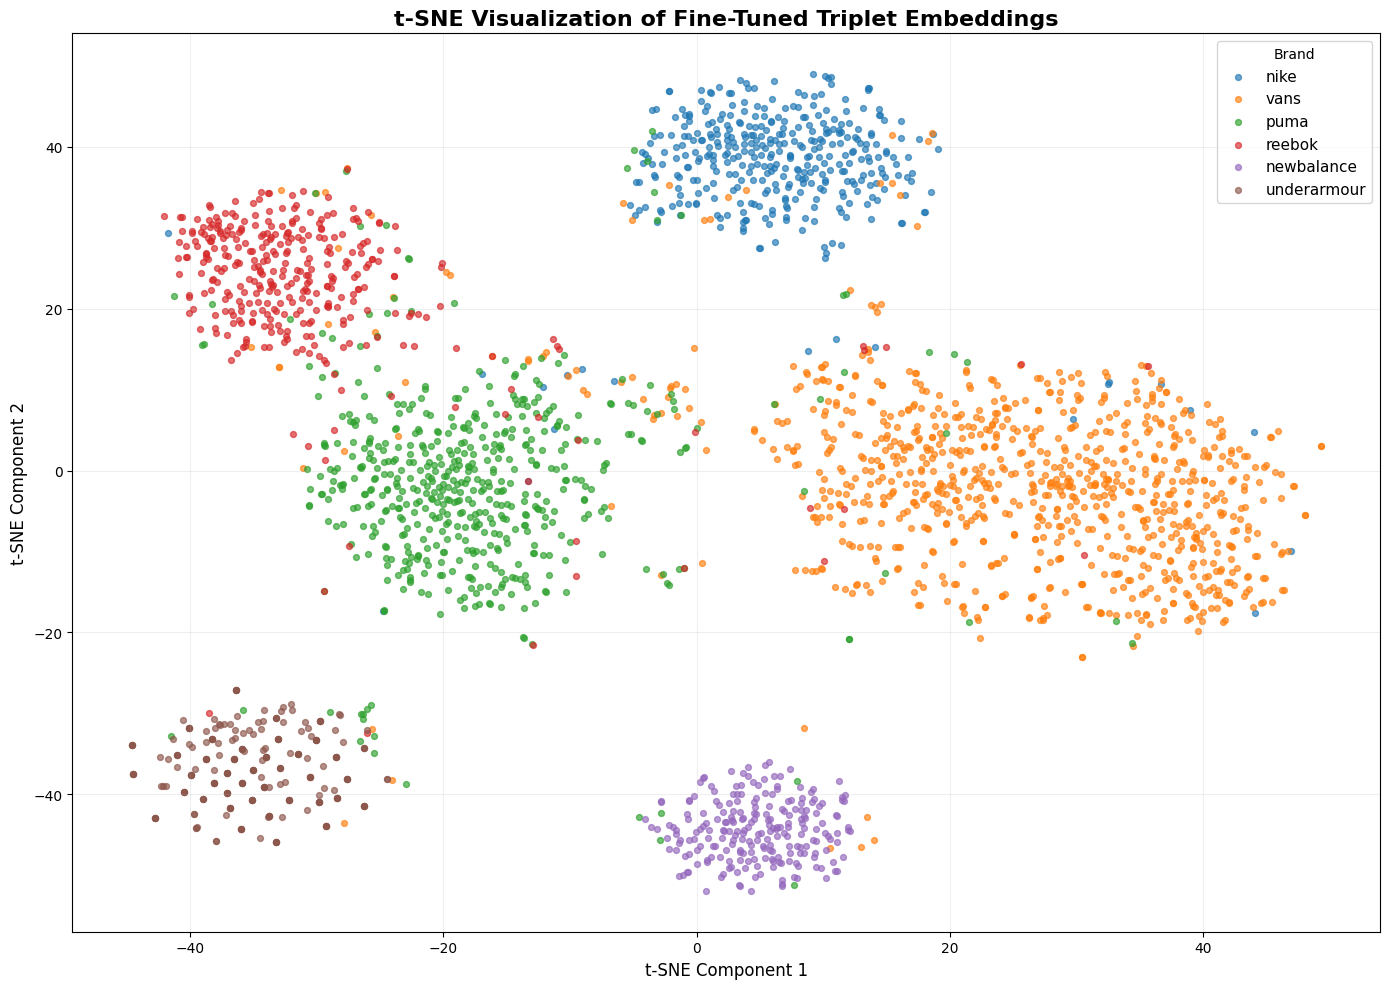

In [43]:
plt.figure(
    figsize=(14,10)
)

brand_order = [
    "nike",
    "vans",
    "puma",
    "reebok",
    "newbalance",
    "underarmour"
]

for brand in brand_order:

    subset = tsne_df[
        tsne_df["brand"] == brand
    ]

    plt.scatter(
        subset["x"],
        subset["y"],
        label=brand,
        alpha=0.65,
        s=18
    )

plt.title(
    "t-SNE Visualization of Fine-Tuned Triplet Embeddings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "t-SNE Component 1",
    fontsize=12
)

plt.ylabel(
    "t-SNE Component 2",
    fontsize=12
)

plt.legend(
    title="Brand",
    fontsize=11
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()